# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from scipy.stats import kendalltau
from src.llm.ollama_client import OllamaClient

# 2. Model Setup

In [2]:
llm = OllamaClient(model="mistral")  # or GPT-4o equivalent

# 3. Evaluation function (PCS + Tau compatible)

In [3]:
def evaluate(question, answer, temperature=0.0):
    prompt = f"""
You are an evaluator.

Score how well the answer relates to the question.

Rules:
- Score from 0 to 10
- Output ONLY the number
- Do NOT explain

Question: {question}
Answer: {answer}

Score:
"""

    output = llm.generate(prompt, temperature=temperature)

    match = re.search(r"\d+", output)
    return int(match.group()) if match else None

# 4. Language prompts

In [4]:
prompts = {
    "EN": "In your own words, could you tell us of one thing you are looking forward to over the next 12 months?",
    "DE": "Könnten Sie uns in Ihren eigenen Worten sagen, auf welche eine Sache Sie sich in den nächsten 12 Monaten besonders freuen?",
    "PT": "Por palavras, suas, pode dizer-nos o que espera nos próximos 12 meses?"
}

# 5. Experiment runner

In [5]:
def run_experiment(prompt, answer, temperature=0.7, n_runs=3, n_samples=3):
    runs = []

    for _ in range(n_runs):
        scores = []

        for _ in range(n_samples):
            s = evaluate(prompt, answer, temperature)
            if s is not None:
                scores.append(s)

        runs.append(scores)

    return runs

# 6. PCS function (per language × temperature)

In [6]:
def pcs(runs, tol=0.1):
    run_means = [np.mean(run) for run in runs]

    agreements = 0
    total = 0

    for i in range(len(run_means)):
        for j in range(i + 1, len(run_means)):
            agreements += int(abs(run_means[i] - run_means[j]) < tol)
            total += 1

    return agreements / total if total > 0 else 0

# 8. Kendall Tau stability

In [7]:
def ranking_stability(runs):
    taus = []

    for i in range(len(runs)):
        for j in range(i + 1, len(runs)):
            tau, _ = kendalltau(runs[i], runs[j])
            if not np.isnan(tau):
                taus.append(tau)

    return np.mean(taus) if taus else 0

# 9. Run experiment

In [8]:
answer = "Christmas"
temps = [0.0, 0.3, 0.7, 1.0]

rows = []

for lang, prompt in prompts.items():
    for t in temps:

        runs = run_experiment(prompt, answer, temperature=t)

        flat_scores = [s for run in runs for s in run]

        rows.append({
            "language": lang,
            "temperature": t,
            "mean": np.mean(flat_scores),
            "std": np.std(flat_scores),
            "PCS": pcs(runs),
            "tau": ranking_stability(runs)
        })

df = pd.DataFrame(rows)
df

[Ollama] 2.73s | temp=0.0
Output:  3
[Ollama] 0.45s | temp=0.0
Output:  3
[Ollama] 0.44s | temp=0.0
Output:  3
[Ollama] 0.47s | temp=0.0
Output:  3
[Ollama] 0.47s | temp=0.0
Output:  3
[Ollama] 0.44s | temp=0.0
Output:  3
[Ollama] 0.46s | temp=0.0
Output:  3
[Ollama] 2.17s | temp=0.0
Output:  3
[Ollama] 1.41s | temp=0.0
Output:  3
[Ollama] 0.62s | temp=0.3
Output:  3
[Ollama] 0.51s | temp=0.3
Output:  3
[Ollama] 0.52s | temp=0.3
Output:  3
[Ollama] 0.71s | temp=0.3
Output:  3
[Ollama] 0.66s | temp=0.3
Output:  3
[Ollama] 0.50s | temp=0.3
Output:  3
[Ollama] 0.51s | temp=0.3
Output:  3
[Ollama] 0.53s | temp=0.3
Output:  3
[Ollama] 0.52s | temp=0.3
Output:  3
[Ollama] 0.53s | temp=0.7
Output:  3
[Ollama] 0.52s | temp=0.7
Output:  3
[Ollama] 0.52s | temp=0.7
Output:  2
[Ollama] 0.51s | temp=0.7
Output:  3
[Ollama] 0.52s | temp=0.7
Output:  3
[Ollama] 0.52s | temp=0.7
Output:  3
[Ollama] 0.54s | temp=0.7
Output:  2
[Ollama] 0.52s | temp=0.7
Output:  3
[Ollama] 0.53s | temp=0.7
Output:  3
[

,language,temperature,mean,std,PCS,tau
0,EN,0.0,3.000000,0.00000,1.000000,0.0
1,EN,0.3,3.000000,0.00000,1.000000,0.0
2,EN,0.7,2.777778,0.41574,0.333333,-0.5
3,EN,1.0,2.777778,0.41574,0.333333,0.0
4,DE,0.0,0.000000,0.00000,1.000000,0.0
5,DE,0.3,0.000000,0.00000,1.000000,0.0
6,DE,0.7,0.000000,0.00000,1.000000,0.0
7,DE,1.0,0.000000,0.00000,1.000000,0.0
8,PT,0.0,0.000000,0.00000,1.000000,0.0
9,PT,0.3,0.000000,0.00000,1.000000,0.0


# 10. Summary table

In [9]:
summary = df.pivot_table(
    values=["mean", "std", "PCS", "tau"],
    index="language",
    columns="temperature"
)

summary

PCS                          mean                           std  \
temperature  0.0  0.3       0.7       1.0  0.0  0.3       0.7       1.0  0.0   
language                                                                       
DE           1.0  1.0  1.000000  1.000000  0.0  0.0  0.000000  0.000000  0.0   
EN           1.0  1.0  0.333333  0.333333  3.0  3.0  2.777778  2.777778  0.0   
PT           1.0  1.0  1.000000  1.000000  0.0  0.0  0.000000  0.000000  0.0   

                                    tau                 
temperature  0.3      0.7      1.0  0.0  0.3  0.7  1.0  
language                                                
DE           0.0  0.00000  0.00000  0.0  0.0  0.0  0.0  
EN           0.0  0.41574  0.41574  0.0  0.0 -0.5  0.0  
PT           0.0  0.00000  0.00000  0.0  0.0  0.0  0.0

# 11. Visualization

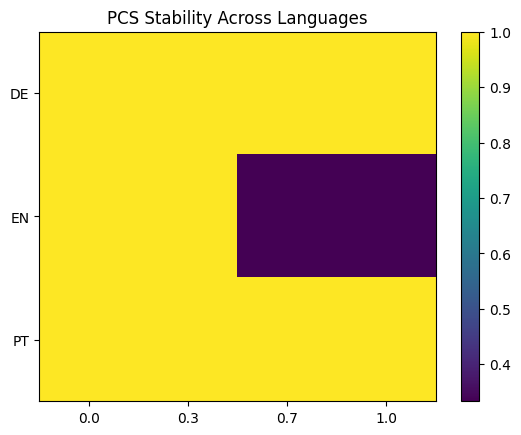

In [10]:
pivot = df.pivot(index="language", columns="temperature", values="PCS")

im = plt.imshow(pivot, aspect="auto")
plt.colorbar(im)

plt.title("PCS Stability Across Languages")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns)

plt.show()

# 12. Translation-controlled evaluation

In [11]:
def evaluate_translated(question, answer, temperature=0.0):
    prompt = f"""
Translate the question and answer into English.
Then evaluate relevance.

Return ONLY a number from 0 to 10.

Question: {question}
Answer: {answer}

Score:
"""

    output = llm.generate(prompt, temperature=temperature)

    match = re.search(r"\d+", output)
    return int(match.group()) if match else None

## 🧠 Core Finding

Evaluation behavior varies significantly across languages, even when the underlying semantic task is identical.

Portuguese evaluations collapse to a constant score (mean = 0), indicating systematic failure.

German evaluations produce low scores with limited variability.

English evaluations show higher and more structured responses, though still low in magnitude.

## 🔍 Interpretation

These results suggest that LLM-based evaluators are highly sensitive to the language of the input, and do not operate as language-invariant scoring systems.

The observed asymmetry indicates that evaluation performance depends not only on semantic content, but also on linguistic context and instruction alignment.

## 🚨 Implication

LLM-based evaluation systems cannot be assumed to produce comparable scores across languages without explicit calibration or translation control.